In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

In [2]:
BASE = Path("dietstudy_analyses-master")

MAPS = BASE / "data" / "maps"
MICRO = BASE / "data" / "microbiome"
PROC = MICRO / "processed_sample"
PROCRUSTES = BASE / "data" / "procrustes"

In [3]:
food_map = pd.read_csv(
    MAPS / "food_map_no_soy.txt",
    sep="\t"
)

print(food_map.shape)

food_map.head()

(532, 29)


,#SampleID,UserName,StudyDayNo,StudyDate,Sample.Week.Day,DietDayNo,Diet.Record.Date,Diet.Week.Day,Gender,Age,Weight,Height,BMI,Supplement,Waist.Circumference,Study.Status,oilGrams.assigned,fecal.status,fecal.time,BMI.1,Weight.Change,Run1.Plate,Run2.Rerun,SampleOrder,SampleType,Timing,Activity.Factor,Medications,Dietary.Supp
0,MCT.f.0001,MCTs01,1,1/31/17,Tuesday,0,1/30/17,Monday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,12:00 PM,25.0,-0.4,5.0,NaN,54.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
1,MCT.f.0002,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
2,MCT.f.0003,MCTs01,3,2/2/17,Thursday,2,2/1/17,Wednesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,10:30 AM,25.0,-0.4,1.0,NaN,59.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
3,MCT.f.0004,MCTs01,4,2/3/17,Friday,3,2/2/17,Thursday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,8:55 AM,25.0,-0.4,5.0,NaN,32.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
4,MCT.f.0005,MCTs01,5,2/4/17,Saturday,4,2/3/17,Friday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,1:40 PM,25.0,-0.4,2.0,Yes,89.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc


In [4]:
food_map.columns.tolist()

['#SampleID',
 'UserName',
 'StudyDayNo',
 'StudyDate',
 'Sample.Week.Day',
 'DietDayNo',
 'Diet.Record.Date',
 'Diet.Week.Day',
 'Gender',
 'Age',
 'Weight',
 'Height',
 'BMI',
 'Supplement',
 'Waist.Circumference',
 'Study.Status',
 'oilGrams.assigned',
 'fecal.status',
 'fecal.time',
 'BMI.1',
 'Weight.Change',
 'Run1.Plate',
 'Run2.Rerun',
 'SampleOrder',
 'SampleType',
 'Timing',
 'Activity.Factor',
 'Medications',
 'Dietary.Supp']

In [5]:
important_cols = [
    "#SampleID",
    "UserName",
    "StudyDayNo",
    "DietDayNo",
    "Timing",
    "Supplement",
    "oilGrams.assigned"
]

food_map[important_cols].head(10)

,#SampleID,UserName,StudyDayNo,DietDayNo,Timing,Supplement,oilGrams.assigned
0,MCT.f.0001,MCTs01,1,0,Pre,EVOO,0
1,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0
2,MCT.f.0003,MCTs01,3,2,Pre,EVOO,0
3,MCT.f.0004,MCTs01,4,3,Pre,EVOO,0
4,MCT.f.0005,MCTs01,5,4,Pre,EVOO,0
5,MCT.f.0006,MCTs01,6,5,Pre,EVOO,0
6,MCT.f.0007,MCTs01,7,6,Pre,EVOO,0
7,MCT.f.0008,MCTs01,8,7,Transition,EVOO,6
8,MCT.f.0009,MCTs01,9,8,Transition,EVOO,12
9,MCT.f.0010,MCTs01,10,9,Transition,EVOO,12


In [6]:
print("Unique participants:", food_map["UserName"].nunique())

print("Unique stool samples:", food_map["#SampleID"].nunique())

print("Study days:")
print(sorted(food_map["StudyDayNo"].unique()))

Unique participants: 32
Unique stool samples: 532
Study days:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]


In [7]:
gut_clr = pd.read_csv(
    PROC / "taxonomy_clr_s.txt",
    sep="\t"
)

print(gut_clr.shape)

gut_clr.head()

(223, 484)


,#taxonomy,MCT.f.0002,MCT.f.0003,MCT.f.0004,MCT.f.0005,MCT.f.0006,MCT.f.0007,MCT.f.0008,MCT.f.0009,MCT.f.0010,MCT.f.0011,MCT.f.0012,MCT.f.0013,MCT.f.0014,MCT.f.0016,MCT.f.0017,MCT.f.0035,MCT.f.0036,MCT.f.0037,MCT.f.0038,MCT.f.0039,MCT.f.0042,MCT.f.0043,MCT.f.0044,MCT.f.0045,MCT.f.0048,MCT.f.0049,MCT.f.0050,MCT.f.0051,MCT.f.0052,MCT.f.0053,MCT.f.0054,MCT.f.0055,MCT.f.0056,MCT.f.0057,MCT.f.0058,MCT.f.0059,MCT.f.0060,MCT.f.0061,MCT.f.0063,MCT.f.0065,MCT.f.0066,MCT.f.0067,MCT.f.0068,MCT.f.0069,MCT.f.0070,MCT.f.0071,MCT.f.0072,MCT.f.0074,MCT.f.0075,MCT.f.0076,MCT.f.0077,MCT.f.0078,MCT.f.0080,MCT.f.0081,MCT.f.0083,MCT.f.0085,MCT.f.0086,MCT.f.0089,MCT.f.0091,MCT.f.0094,MCT.f.0095,MCT.f.0098,MCT.f.0099,MCT.f.0103,MCT.f.0104,MCT.f.0106,MCT.f.0107,MCT.f.0108,MCT.f.0109,MCT.f.0110,MCT.f.0111,MCT.f.0112,MCT.f.0113,MCT.f.0114,MCT.f.0115,MCT.f.0116,MCT.f.0117,MCT.f.0118,MCT.f.0119,MCT.f.0120,MCT.f.0121,MCT.f.0122,MCT.f.0123,MCT.f.0124,MCT.f.0125,MCT.f.0126,MCT.f.0127,MCT.f.0128,MCT.f.0129,MCT.f.0130,MCT.f.0131,MCT.f.0132,MCT.f.0133,MCT.f.0134,MCT.f.0135,MCT.f.0136,MCT.f.0137,MCT.f.0138,MCT.f.0139,...,MCT.f.0513,MCT.f.0514,MCT.f.0515,MCT.f.0516,MCT.f.0517,MCT.f.0519,MCT.f.0520,MCT.f.0522,MCT.f.0523,MCT.f.0524,MCT.f.0525,MCT.f.0526,MCT.f.0527,MCT.f.0528,MCT.f.0529,MCT.f.0530,MCT.f.0532,MCT.f.0533,MCT.f.0534,MCT.f.0535,MCT.f.0536,MCT.f.0538,MCT.f.0539,MCT.f.0540,MCT.f.0541,MCT.f.0543,MCT.f.0544,MCT.f.0545,MCT.f.0546,MCT.f.0547,MCT.f.0548,MCT.f.0549,MCT.f.0550,MCT.f.0551,MCT.f.0552,MCT.f.0553,MCT.f.0554,MCT.f.0555,MCT.f.0556,MCT.f.0557,MCT.f.0558,MCT.f.0559,MCT.f.0560,MCT.f.0561,MCT.f.0562,MCT.f.0564,MCT.f.0565,MCT.f.0566,MCT.f.0567,MCT.f.0568,MCT.f.0570,MCT.f.0573,MCT.f.0574,MCT.f.0575,MCT.f.0577,MCT.f.0578,MCT.f.0579,MCT.f.0580,MCT.f.0581,MCT.f.0582,MCT.f.0583,MCT.f.0585,MCT.f.0586,MCT.f.0587,MCT.f.0590,MCT.f.0592,MCT.f.0593,MCT.f.0595,MCT.f.0596,MCT.f.0597,MCT.f.0598,MCT.f.0599,MCT.f.0600,MCT.f.0601,MCT.f.0602,MCT.f.0603,MCT.f.0604,MCT.f.0605,MCT.f.0606,MCT.f.0607,MCT.f.0608,MCT.f.0609,MCT.f.0610,MCT.f.0611,MCT.f.0612,MCT.f.0613,MCT.f.0614,MCT.f.0615,MCT.f.0616,MCT.f.0617,MCT.f.0618,MCT.f.0619,MCT.f.0620,MCT.f.0621,MCT.f.0622,MCT.f.0623,MCT.f.0624,MCT.f.0625,MCT.f.0627,MCT.f.0628
0,k__Bacteria;NA;NA;NA;NA;NA;NA,1.186262,1.625297,0.741324,0.392266,0.976799,1.062720,1.083087,0.998056,0.703716,0.919841,0.713855,1.020518,1.348468,1.586656,0.939026,0.459147,0.321221,0.516737,0.473078,0.957797,0.216601,0.364150,0.474397,0.463377,0.663055,0.476705,0.752566,0.603681,1.361214,1.258993,1.523713,1.657115,1.365074,1.854090,1.928492,1.039493,1.724442,3.678433,4.153057,1.658452,3.312569,2.136534,1.758687,1.263723,1.357564,1.578339,1.948913,1.490599,1.610447,2.259113,1.782814,1.179617,0.791247,1.325217,1.256797,1.407186,0.894014,0.942426,0.721918,0.564922,1.162342,1.727744,0.997355,1.518613,1.401246,1.629137,0.846363,1.736951,0.892990,0.860469,1.060014,1.425064,1.051513,1.450390,0.995303,0.765818,1.036239,1.069090,1.185474,0.859424,0.514783,0.550192,0.334728,0.475612,0.084269,-0.271437,0.059056,0.561101,1.094247,1.247498,0.881654,0.130998,0.903863,0.532748,0.476807,-0.000429,1.227501,2.056878,1.048533,...,2.414327,2.474797,2.801059,2.336083,2.520247,2.594460,2.265397,2.004279,2.277332,2.688413,2.166763,4.867453,1.938589,1.417703,1.042764,0.808262,2.624075,2.001252,1.401515,2.569267,0.684615,1.281450,1.103008,1.430829,2.703190,2.387492,2.597634,-0.328930,-0.126613,0.031054,-0.054934,0.100109,-0.436540,0.350518,0.055231,0.359289,1.896041,0.226464,0.280745,0.126827,0.279650,-0.041720,-0.062834,0.039272,1.647242,1.171402,1.263413,1.475456,1.619162,1.043859,1.257310,1.810277,1.178823,1.126485,1.740287,1.277353,2.712988,3.553084,3.205500,4.034783,2.940212,3.364294,3.522823,3.618382,3.186626,3.497775,3.157586,2.900585,0.750535,0.987051,0.904620,0.311783,0.462916,0.557632,0.945117,0.509569,1.189043,0.964554,0.601755,0.495348,1.086351,1.040180,1.140420,0.798946,0.629241,1.478118,1.732400,1.444339,2.969402,1.270691,1.302527,0.801082,2.234895,1.111533,1.233751,2.4191

In [8]:
gut_long = gut_clr.melt(
    id_vars="#taxonomy",
    var_name="#SampleID",
    value_name="CLR_abundance"
)

print(gut_long.shape)

gut_long.head()

(107709, 3)


,#taxonomy,#SampleID,CLR_abundance
0,k__Bacteria;NA;NA;NA;NA;NA;NA,MCT.f.0002,1.186262
1,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,MCT.f.0002,1.080382
2,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,MCT.f.0002,3.469741
3,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,MCT.f.0002,-3.774249
4,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,MCT.f.0002,-0.812418


In [9]:
print(
    gut_long["#taxonomy"].nunique()
)

223


In [10]:
gut_meta = gut_long.merge(
    food_map,
    on="#SampleID",
    how="inner"
)

print(gut_meta.shape)

gut_meta.head()

(98789, 31)


,#taxonomy,#SampleID,CLR_abundance,UserName,StudyDayNo,StudyDate,Sample.Week.Day,DietDayNo,Diet.Record.Date,Diet.Week.Day,Gender,Age,Weight,Height,BMI,Supplement,Waist.Circumference,Study.Status,oilGrams.assigned,fecal.status,fecal.time,BMI.1,Weight.Change,Run1.Plate,Run2.Rerun,SampleOrder,SampleType,Timing,Activity.Factor,Medications,Dietary.Supp
0,k__Bacteria;NA;NA;NA;NA;NA;NA,MCT.f.0002,1.186262,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
1,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,MCT.f.0002,1.080382,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
2,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,MCT.f.0002,3.469741,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
3,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,MCT.f.0002,-3.774249,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
4,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,MCT.f.0002,-0.812418,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc


In [11]:
gut_meta[
    [
        "UserName",
        "StudyDayNo",
        "#SampleID",
        "#taxonomy",
        "CLR_abundance"
    ]
].head(20)

,UserName,StudyDayNo,#SampleID,#taxonomy,CLR_abundance
0,MCTs01,2,MCT.f.0002,k__Bacteria;NA;NA;NA;NA;NA;NA,1.186262
1,MCTs01,2,MCT.f.0002,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,1.080382
2,MCTs01,2,MCT.f.0002,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,3.469741
3,MCTs01,2,MCT.f.0002,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-3.774249
4,MCTs01,2,MCT.f.0002,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-0.812418
5,MCTs01,2,MCT.f.0002,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-0.981041
6,MCTs01,2,MCT.f.0002,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,1.975144
7,MCTs01,2,MCT.f.0002,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,0.844167
8,MCTs01,2,MCT.f.0002,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Micrococcales;f__Cellulomonadaceae;g__Cellulomonas;s__Cellulomona...,-4.542395
9,MCTs01,2,MCT.f.0002,k__Bacteria;p__Actinobacteria;c__Coriobacteriia;o__Coriobacteriales;f__Coriobacteriaceae;g__Collinsella;NA,0.308923


In [12]:
food_file = (
    PROCRUSTES
    / "data_username_1day"
    / "MCTs01_food.txt"
)

food_1 = pd.read_csv(
    food_file,
    sep="\t"
)

print(food_1.shape)

food_1.head()

(1452, 17)


,#FoodID,MCT.f.0002,MCT.f.0003,MCT.f.0004,MCT.f.0005,MCT.f.0006,MCT.f.0007,MCT.f.0008,MCT.f.0009,MCT.f.0010,MCT.f.0011,MCT.f.0012,MCT.f.0013,MCT.f.0014,MCT.f.0016,MCT.f.0017,taxonomy
0,3 MUSKETEERS Bar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,L1_Sugars_Sweets_and_Beverages;L2_Sugars_and_sweets;L3_Candies;L4_Candies;L5_Nougat_candy;3_MUSKETEERS_Bar
1,Alfalfa sprouts raw,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,L1_Vegetables;L2_Other_vegetables;L3_Other_vegetables_raw;L4_Other_vegetables_raw;L5_;Alfalfa_sprouts_raw
2,Almond butter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,L1_Dry_Beans_Peas_Other_Legumes_Nuts_and_Seeds;L2_Nuts_nut_butters_and_nut_mixtures;L3_Nut_butters;L4_Nut_butters;L5...
3,Almonds chocolate covered,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,L1_Sugars_Sweets_and_Beverages;L2_Sugars_and_sweets;L3_Candies;L4_Candies;L5_Almonds;Almonds_chocolate_covered
4,Almonds dry roasted assume salted,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,L1_Dry_Beans_Peas_Other_Legumes_Nuts_and_Seeds;L2_Nuts_nut_butters_and_nut_mixtures;L3_Nuts;L4_Nuts_NFS;L5_Almonds;A...


In [13]:
food_long = food_1.melt(
    id_vars=["#FoodID", "taxonomy"],
    var_name="#SampleID",
    value_name="food_grams"
)

print(food_long.shape)

food_long.head()

(21780, 4)


,#FoodID,taxonomy,#SampleID,food_grams
0,3 MUSKETEERS Bar,L1_Sugars_Sweets_and_Beverages;L2_Sugars_and_sweets;L3_Candies;L4_Candies;L5_Nougat_candy;3_MUSKETEERS_Bar,MCT.f.0002,0.0
1,Alfalfa sprouts raw,L1_Vegetables;L2_Other_vegetables;L3_Other_vegetables_raw;L4_Other_vegetables_raw;L5_;Alfalfa_sprouts_raw,MCT.f.0002,0.0
2,Almond butter,L1_Dry_Beans_Peas_Other_Legumes_Nuts_and_Seeds;L2_Nuts_nut_butters_and_nut_mixtures;L3_Nut_butters;L4_Nut_butters;L5...,MCT.f.0002,0.0
3,Almonds chocolate covered,L1_Sugars_Sweets_and_Beverages;L2_Sugars_and_sweets;L3_Candies;L4_Candies;L5_Almonds;Almonds_chocolate_covered,MCT.f.0002,0.0
4,Almonds dry roasted assume salted,L1_Dry_Beans_Peas_Other_Legumes_Nuts_and_Seeds;L2_Nuts_nut_butters_and_nut_mixtures;L3_Nuts;L4_Nuts_NFS;L5_Almonds;A...,MCT.f.0002,0.0


In [14]:
food_long = food_long[
    food_long["food_grams"] > 0
]

print(food_long.shape)

(347, 4)


In [15]:
food_meta = food_long.merge(
    food_map,
    on="#SampleID",
    how="inner"
)

food_meta.head()

,#FoodID,taxonomy,#SampleID,food_grams,UserName,StudyDayNo,StudyDate,Sample.Week.Day,DietDayNo,Diet.Record.Date,Diet.Week.Day,Gender,Age,Weight,Height,BMI,Supplement,Waist.Circumference,Study.Status,oilGrams.assigned,fecal.status,fecal.time,BMI.1,Weight.Change,Run1.Plate,Run2.Rerun,SampleOrder,SampleType,Timing,Activity.Factor,Medications,Dietary.Supp
0,Beer,L1_Sugars_Sweets_and_Beverages;L2_Alcoholic_beverages;L3_Beers_and_ales;L4_;L5_;Beer,MCT.f.0002,28.944000,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
1,Cheese Cheddar,L1_Milk_and_Milk_Products;L2_Cheeses;L3_Natural_cheeses;L4_Natural_cheeses;L5_Cheddar_Colby_Feta_Fontina_Goat;Cheese...,MCT.f.0002,17.868125,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
2,Coffee made from ground regular,L1_Sugars_Sweets_and_Beverages;L2_Nonalcoholic_beverages;L3_Coffee;L4_Coffee;L5_Coffee_from_ground;Coffee_made_from_...,MCT.f.0002,5.777920,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
3,Corn soup cream of prepared with milk,L1_Vegetables;L2_Other_vegetables;L3_Vegetable_soups;L4_Vegetable_soups;L5_Corn_or_gazpacho;Corn_soup_cream_of_prepa...,MCT.f.0002,18.832500,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
4,Crackers rice,L1_Grain_Product;L2_Crackers_and_salty_snacks_from_grain;L3_Nonsweet_crackers;L4_Nonsweet_crackers;L5_Cracker_rice;C...,MCT.f.0002,40.023000,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc


In [16]:
food_meta[
    [
        "UserName",
        "StudyDayNo",
        "#SampleID",
        "#FoodID",
        "food_grams"
    ]
].head(30)

,UserName,StudyDayNo,#SampleID,#FoodID,food_grams
0,MCTs01,2,MCT.f.0002,Beer,28.944000
1,MCTs01,2,MCT.f.0002,Cheese Cheddar,17.868125
2,MCTs01,2,MCT.f.0002,Coffee made from ground regular,5.777920
3,MCTs01,2,MCT.f.0002,Corn soup cream of prepared with milk,18.832500
4,MCTs01,2,MCT.f.0002,Crackers rice,40.023000
5,MCTs01,2,MCT.f.0002,Garlic sauce,2.710350
6,MCTs01,2,MCT.f.0002,Guacamole,3.883819
7,MCTs01,2,MCT.f.0002,Hot pepper sauce,0.724500
8,MCTs01,2,MCT.f.0002,Life plain and cinnamon,41.151000
9,MCTs01,2,MCT.f.0002,Milk cows fluid skim or nonfat 0 5 or less butterfat,44.847360


In [17]:
food_meta.groupby("#SampleID").size().describe()

count    15.000000
mean     23.133333
std       4.437932
min      16.000000
25%      21.500000
50%      22.000000
75%      25.000000
max      34.000000
dtype: float64

In [18]:
gut_meta.groupby("#SampleID").size().describe()

count    443.0
mean     223.0
std        0.0
min      223.0
25%      223.0
50%      223.0
75%      223.0
max      223.0
dtype: float64

In [19]:
sample_df = food_map[
    [
        "#SampleID",
        "UserName",
        "StudyDayNo",
        "DietDayNo",
        "Timing",
        "Supplement",
        "oilGrams.assigned"
    ]
].copy()

sample_df = sample_df.sort_values(
    ["UserName", "StudyDayNo"]
)

sample_df.head(20)

,#SampleID,UserName,StudyDayNo,DietDayNo,Timing,Supplement,oilGrams.assigned
0,MCT.f.0001,MCTs01,1,0,Pre,EVOO,0
1,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0
2,MCT.f.0003,MCTs01,3,2,Pre,EVOO,0
3,MCT.f.0004,MCTs01,4,3,Pre,EVOO,0
4,MCT.f.0005,MCTs01,5,4,Pre,EVOO,0
5,MCT.f.0006,MCTs01,6,5,Pre,EVOO,0
6,MCT.f.0007,MCTs01,7,6,Pre,EVOO,0
7,MCT.f.0008,MCTs01,8,7,Transition,EVOO,6
8,MCT.f.0009,MCTs01,9,8,Transition,EVOO,12
9,MCT.f.0010,MCTs01,10,9,Transition,EVOO,12


In [20]:
sample_df["PrevSampleID"] = (
    sample_df
    .groupby("UserName")["#SampleID"]
    .shift(1)
)

sample_df["PrevStudyDay"] = (
    sample_df
    .groupby("UserName")["StudyDayNo"]
    .shift(1)
)

sample_df.head(20)

,#SampleID,UserName,StudyDayNo,DietDayNo,Timing,Supplement,oilGrams.assigned,PrevSampleID,PrevStudyDay
0,MCT.f.0001,MCTs01,1,0,Pre,EVOO,0,NaN,NaN
1,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0
2,MCT.f.0003,MCTs01,3,2,Pre,EVOO,0,MCT.f.0002,2.0
3,MCT.f.0004,MCTs01,4,3,Pre,EVOO,0,MCT.f.0003,3.0
4,MCT.f.0005,MCTs01,5,4,Pre,EVOO,0,MCT.f.0004,4.0
5,MCT.f.0006,MCTs01,6,5,Pre,EVOO,0,MCT.f.0005,5.0
6,MCT.f.0007,MCTs01,7,6,Pre,EVOO,0,MCT.f.0006,6.0
7,MCT.f.0008,MCTs01,8,7,Transition,EVOO,6,MCT.f.0007,7.0
8,MCT.f.0009,MCTs01,9,8,Transition,EVOO,12,MCT.f.0008,8.0
9,MCT.f.0010,MCTs01,10,9,Transition,EVOO,12,MCT.f.0009,9.0


In [21]:
gut_after = gut_long.rename(
    columns={
        "#SampleID": "CurrentSampleID",
        "CLR_abundance": "GutAfterCLR"
    }
)

gut_after.head()

,#taxonomy,CurrentSampleID,GutAfterCLR
0,k__Bacteria;NA;NA;NA;NA;NA;NA,MCT.f.0002,1.186262
1,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,MCT.f.0002,1.080382
2,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,MCT.f.0002,3.469741
3,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,MCT.f.0002,-3.774249
4,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,MCT.f.0002,-0.812418


In [22]:
gut_before = gut_long.rename(
    columns={
        "#SampleID": "PrevSampleID",
        "CLR_abundance": "GutBeforeCLR"
    }
)

gut_before.head()

,#taxonomy,PrevSampleID,GutBeforeCLR
0,k__Bacteria;NA;NA;NA;NA;NA;NA,MCT.f.0002,1.186262
1,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,MCT.f.0002,1.080382
2,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,MCT.f.0002,3.469741
3,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,MCT.f.0002,-3.774249
4,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,MCT.f.0002,-0.812418


In [23]:
temporal_df = sample_df.rename(
    columns={
        "#SampleID": "CurrentSampleID"
    }
)

temporal_df.head()

,CurrentSampleID,UserName,StudyDayNo,DietDayNo,Timing,Supplement,oilGrams.assigned,PrevSampleID,PrevStudyDay
0,MCT.f.0001,MCTs01,1,0,Pre,EVOO,0,NaN,NaN
1,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0
2,MCT.f.0003,MCTs01,3,2,Pre,EVOO,0,MCT.f.0002,2.0
3,MCT.f.0004,MCTs01,4,3,Pre,EVOO,0,MCT.f.0003,3.0
4,MCT.f.0005,MCTs01,5,4,Pre,EVOO,0,MCT.f.0004,4.0


In [24]:
temporal_df = temporal_df.merge(
    gut_after,
    on="CurrentSampleID",
    how="left"
)

print(temporal_df.shape)

temporal_df.head()

(98878, 11)


,CurrentSampleID,UserName,StudyDayNo,DietDayNo,Timing,Supplement,oilGrams.assigned,PrevSampleID,PrevStudyDay,#taxonomy,GutAfterCLR
0,MCT.f.0001,MCTs01,1,0,Pre,EVOO,0,NaN,NaN,NaN,NaN
1,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;NA;NA;NA;NA;NA;NA,1.186262
2,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,1.080382
3,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,3.469741
4,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-3.774249


In [25]:
temporal_df = temporal_df.merge(
    gut_before,
    on=[
        "PrevSampleID",
        "#taxonomy"
    ],
    how="left"
)

print(temporal_df.shape)

temporal_df.head()

(98878, 12)


,CurrentSampleID,UserName,StudyDayNo,DietDayNo,Timing,Supplement,oilGrams.assigned,PrevSampleID,PrevStudyDay,#taxonomy,GutAfterCLR,GutBeforeCLR
0,MCT.f.0001,MCTs01,1,0,Pre,EVOO,0,NaN,NaN,NaN,NaN,NaN
1,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;NA;NA;NA;NA;NA;NA,1.186262,NaN
2,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,1.080382,NaN
3,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,3.469741,NaN
4,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-3.774249,NaN


In [26]:
temporal_df["DeltaCLR"] = (
    temporal_df["GutAfterCLR"]
    - temporal_df["GutBeforeCLR"]
)

temporal_df.head()

,CurrentSampleID,UserName,StudyDayNo,DietDayNo,Timing,Supplement,oilGrams.assigned,PrevSampleID,PrevStudyDay,#taxonomy,GutAfterCLR,GutBeforeCLR,DeltaCLR
0,MCT.f.0001,MCTs01,1,0,Pre,EVOO,0,NaN,NaN,NaN,NaN,NaN,NaN
1,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;NA;NA;NA;NA;NA;NA,1.186262,NaN,NaN
2,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,1.080382,NaN,NaN
3,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,3.469741,NaN,NaN
4,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-3.774249,NaN,NaN


In [27]:
food_diversity = (
    food_meta
    .groupby("#SampleID")["#FoodID"]
    .nunique()
    .reset_index()
)

food_diversity.columns = [
    "CurrentSampleID",
    "NumFoods"
]

food_diversity.head()

,CurrentSampleID,NumFoods
0,MCT.f.0002,22
1,MCT.f.0003,22
2,MCT.f.0004,34
3,MCT.f.0005,28
4,MCT.f.0006,24


In [28]:
temporal_df = temporal_df.merge(
    food_diversity,
    on="CurrentSampleID",
    how="left"
)

temporal_df.head()

,CurrentSampleID,UserName,StudyDayNo,DietDayNo,Timing,Supplement,oilGrams.assigned,PrevSampleID,PrevStudyDay,#taxonomy,GutAfterCLR,GutBeforeCLR,DeltaCLR,NumFoods
0,MCT.f.0001,MCTs01,1,0,Pre,EVOO,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;NA;NA;NA;NA;NA;NA,1.186262,NaN,NaN,22.0
2,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,1.080382,NaN,NaN,22.0
3,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,3.469741,NaN,NaN,22.0
4,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-3.774249,NaN,NaN,22.0


In [29]:
target_food = "Yogurt"

food_subset = food_meta[
    food_meta["#FoodID"]
    .str.contains(target_food, case=False, na=False)
].copy()

print(food_subset.shape)

food_subset.head(20)

(8, 32)


,#FoodID,taxonomy,#SampleID,food_grams,UserName,StudyDayNo,StudyDate,Sample.Week.Day,DietDayNo,Diet.Record.Date,Diet.Week.Day,Gender,Age,Weight,Height,BMI,Supplement,Waist.Circumference,Study.Status,oilGrams.assigned,fecal.status,fecal.time,BMI.1,Weight.Change,Run1.Plate,Run2.Rerun,SampleOrder,SampleType,Timing,Activity.Factor,Medications,Dietary.Supp
21,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,L1_Milk_and_Milk_Products;L2_Milks_and_milk_drinks;L3_Yogurt;L4_Yogurt_fruit_variety;L5_;Yogurt_fruit_variety_nonfat...,MCT.f.0002,21.624,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
43,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,L1_Milk_and_Milk_Products;L2_Milks_and_milk_drinks;L3_Yogurt;L4_Yogurt_fruit_variety;L5_;Yogurt_fruit_variety_nonfat...,MCT.f.0003,21.624,MCTs01,3,2/2/17,Thursday,2,2/1/17,Wednesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,10:30 AM,25.0,-0.4,1.0,NaN,59.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
180,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,L1_Milk_and_Milk_Products;L2_Milks_and_milk_drinks;L3_Yogurt;L4_Yogurt_fruit_variety;L5_;Yogurt_fruit_variety_nonfat...,MCT.f.0008,21.624,MCTs01,8,2/7/17,Tuesday,7,2/6/17,Monday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,6,1.0,9:20 AM,25.0,-0.4,4.0,NaN,46.0,Sample,Transition,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
219,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,L1_Milk_and_Milk_Products;L2_Milks_and_milk_drinks;L3_Yogurt;L4_Yogurt_fruit_variety;L5_;Yogurt_fruit_variety_nonfat...,MCT.f.0010,21.624,MCTs01,10,2/9/17,Thursday,9,2/8/17,Wednesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,12,1.0,8:55 AM,25.0,-0.4,3.0,NaN,52.0,Sample,Transition,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
235,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,L1_Milk_and_Milk_Products;L2_Milks_and_milk_drinks;L3_Yogurt;L4_Yogurt_fruit_variety;L5_;Yogurt_fruit_variety_nonfat...,MCT.f.0011,21.624,MCTs01,11,2/10/17,Friday,10,2/9/17,Thursday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,12,1.0,9:00 AM,25.0,-0.4,5.0,NaN,67.0,Sample,Post,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
257,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,L1_Milk_and_Milk_Products;L2_Milks_and_milk_drinks;L3_Yogurt;L4_Yogurt_fruit_variety;L5_;Yogurt_fruit_variety_nonfat...,MCT.f.0012,21.624,MCTs01,12,2/11/17,Saturday,11,2/10/17,Friday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,12,1.0,12:00 PM,25.0,-0.4,4.0,NaN,7.0,Sample,Post,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
324,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,L1_Milk_and_Milk_Products;L2_Milks_and_milk_drinks;L3_Yogurt;L4_Yogurt_fruit_variety;L5_;Yogurt_fruit_variety_nonfat...,MCT.f.0016,21.624,MCTs01,16,2/15/17,Wednesday,15,2/14/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,12,1.0,9:05 AM,25.0,-0.4,5.0,NaN,17.0,Sample,Post,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
346,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,L1_Milk_and_Milk_Products;L2_Milks_and_milk_drinks;L3_Yogurt;L4_Yogurt_fruit_variety;L5_;Yogurt_fruit_variety_nonfat...,MCT.f.0017,21.624,MCTs01,17,2/16/17,Thursday,16,2/15/17,Wednesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,12,1.0,8:55 AM,25.0,-0.4,1.0,NaN,84.0,Sample,Post,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc


In [30]:
target_taxon = "Bifidobacterium"

tax_subset = temporal_df[
    temporal_df["#taxonomy"]
    .str.contains(target_taxon, case=False, na=False)
].copy()

print(tax_subset.shape)

tax_subset.head()

(3101, 14)


,CurrentSampleID,UserName,StudyDayNo,DietDayNo,Timing,Supplement,oilGrams.assigned,PrevSampleID,PrevStudyDay,#taxonomy,GutAfterCLR,GutBeforeCLR,DeltaCLR,NumFoods
2,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,1.080382,NaN,NaN,22.0
3,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,3.469741,NaN,NaN,22.0
4,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-3.774249,NaN,NaN,22.0
5,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-0.812418,NaN,NaN,22.0
6,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-0.981041,NaN,NaN,22.0


In [31]:
experiment_df = food_subset.merge(
    tax_subset,
    left_on="#SampleID",
    right_on="CurrentSampleID",
    how="inner"
)

print(experiment_df.shape)

experiment_df.head()

(56, 46)


,#FoodID,taxonomy,#SampleID,food_grams,UserName_x,StudyDayNo_x,StudyDate,Sample.Week.Day,DietDayNo_x,Diet.Record.Date,Diet.Week.Day,Gender,Age,Weight,Height,BMI,Supplement_x,Waist.Circumference,Study.Status,oilGrams.assigned_x,fecal.status,fecal.time,BMI.1,Weight.Change,Run1.Plate,Run2.Rerun,SampleOrder,SampleType,Timing_x,Activity.Factor,Medications,Dietary.Supp,CurrentSampleID,UserName_y,StudyDayNo_y,DietDayNo_y,Timing_y,Supplement_y,oilGrams.assigned_y,PrevSampleID,PrevStudyDay,#taxonomy,GutAfterCLR,GutBeforeCLR,DeltaCLR,NumFoods
0,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,L1_Milk_and_Milk_Products;L2_Milks_and_milk_drinks;L3_Yogurt;L4_Yogurt_fruit_variety;L5_;Yogurt_fruit_variety_nonfat...,MCT.f.0002,21.624,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,1.080382,NaN,NaN,22.0
1,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,L1_Milk_and_Milk_Products;L2_Milks_and_milk_drinks;L3_Yogurt;L4_Yogurt_fruit_variety;L5_;Yogurt_fruit_variety_nonfat...,MCT.f.0002,21.624,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,3.469741,NaN,NaN,22.0
2,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,L1_Milk_and_Milk_Products;L2_Milks_and_milk_drinks;L3_Yogurt;L4_Yogurt_fruit_variety;L5_;Yogurt_fruit_variety_nonfat...,MCT.f.0002,21.624,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-3.774249,NaN,NaN,22.0
3,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,L1_Milk_and_Milk_Products;L2_Milks_and_milk_drinks;L3_Yogurt;L4_Yogurt_fruit_variety;L5_;Yogurt_fruit_variety_nonfat...,MCT.f.0002,21.624,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-0.812418,NaN,NaN,22.0
4,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,L1_Milk_and_Milk_Products;L2_Milks_and_milk_drinks;L3_Yogurt;L4_Yogurt_fruit_variety;L5_;Yogurt_fruit_variety_nonfat...,MCT.f.0002,21.624,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,74.6,172.7,25.0,EVOO,NaN,Complete,0,1.0,9:00 AM,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc,MCT.f.0002,MCTs01,2,1,Pre,EVOO,0,MCT.f.0001,1.0,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-0.981041,NaN,NaN,22.0


In [32]:
cols = [
    "UserName_x",
    "StudyDayNo_x",
    "#FoodID",
    "food_grams",
    "#taxonomy",
    "GutBeforeCLR",
    "GutAfterCLR",
    "DeltaCLR"
]

experiment_df[cols].head(30)

,UserName_x,StudyDayNo_x,#FoodID,food_grams,#taxonomy,GutBeforeCLR,GutAfterCLR,DeltaCLR
0,MCTs01,2,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,21.624,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,NaN,1.080382,NaN
1,MCTs01,2,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,21.624,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,NaN,3.469741,NaN
2,MCTs01,2,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,21.624,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,NaN,-3.774249,NaN
3,MCTs01,2,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,21.624,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,NaN,-0.812418,NaN
4,MCTs01,2,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,21.624,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,NaN,-0.981041,NaN
5,MCTs01,2,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,21.624,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,NaN,1.975144,NaN
6,MCTs01,2,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,21.624,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,NaN,0.844167,NaN
7,MCTs01,3,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,21.624,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,1.080382,3.022691,1.942308
8,MCTs01,3,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,21.624,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,3.469741,5.591312,2.121572
9,MCTs01,3,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,21.624,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...,-3.774249,-1.793918,1.980330


In [33]:
experiment_df["DeltaCLR"].describe()

count    42.000000
mean      0.213455
std       1.024047
min      -1.461224
25%      -0.371592
50%      -0.120579
75%       0.928011
max       2.121572
Name: DeltaCLR, dtype: float64

In [35]:
experiment_df["AteFood"] = (
    experiment_df["food_grams"] > 0
).astype(int)

experiment_df[
    [
        "food_grams",
        "AteFood",
        "DeltaCLR"
    ]
].head()

,food_grams,AteFood,DeltaCLR
0,21.624,1,NaN
1,21.624,1,NaN
2,21.624,1,NaN
3,21.624,1,NaN
4,21.624,1,NaN


In [36]:
experiment_df.groupby("AteFood")[
    "DeltaCLR"
].mean()

AteFood
1    0.213455
Name: DeltaCLR, dtype: float64

<Axes: >

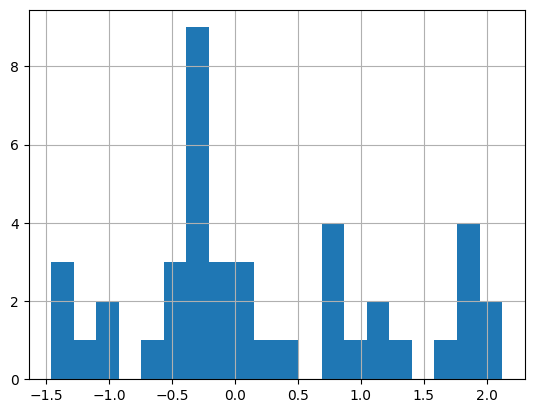

In [37]:
experiment_df["DeltaCLR"].hist(bins=20)

<Axes: xlabel='food_grams', ylabel='DeltaCLR'>

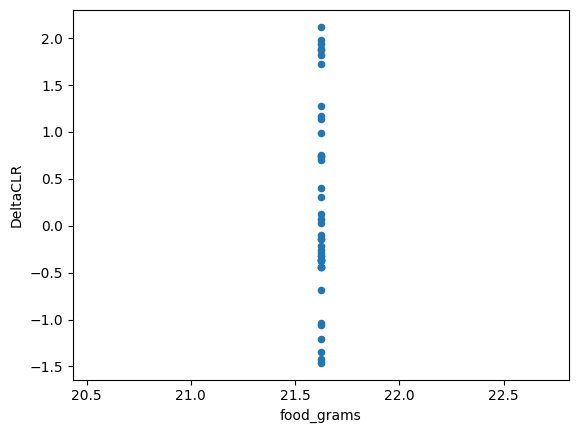

In [38]:
experiment_df.plot.scatter(
    x="food_grams",
    y="DeltaCLR"
)


LOADING LONGITUDINAL SAMPLE METADATA

Metadata shape:
(532, 29)

Metadata preview:
    #SampleID UserName  StudyDayNo StudyDate Sample.Week.Day  DietDayNo Diet.Record.Date Diet.Week.Day Gender   Age  Weight  Height   BMI Supplement  Waist.Circumference Study.Status  oilGrams.assigned  fecal.status fecal.time  BMI.1  \
0  MCT.f.0001   MCTs01           1   1/31/17         Tuesday          0          1/30/17        Monday      F  25.9    74.6   172.7  25.0       EVOO                  NaN     Complete                  0           1.0   12:00 PM   25.0   
1  MCT.f.0002   MCTs01           2    2/1/17       Wednesday          1          1/31/17       Tuesday      F  25.9    74.6   172.7  25.0       EVOO                  NaN     Complete                  0           1.0    9:00 AM   25.0   
2  MCT.f.0003   MCTs01           3    2/2/17        Thursday          2           2/1/17     Wednesday      F  25.9    74.6   172.7  25.0       EVOO                  NaN     Complete                  0    

c:\Users\tttgg\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



Food: Salmon
Taxon: Bifidobacterium

Interpretation:
---------------
This tests whether eating:
    Salmon

is associated with temporal change in:
    Bifidobacterium

between consecutive stool samples.

Number of observations: 7
Mean DeltaCLR: nan
Median DeltaCLR: nan
Standard deviation: nan


c:\Users\tttgg\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



Food: Salmon
Taxon: Faecalibacterium

Interpretation:
---------------
This tests whether eating:
    Salmon

is associated with temporal change in:
    Faecalibacterium

between consecutive stool samples.

Number of observations: 1
Mean DeltaCLR: nan
Median DeltaCLR: nan
Standard deviation: nan


c:\Users\tttgg\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\tttgg\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



Food: Salmon
Taxon: Roseburia

Interpretation:
---------------
This tests whether eating:
    Salmon

is associated with temporal change in:
    Roseburia

between consecutive stool samples.

Number of observations: 5
Mean DeltaCLR: nan
Median DeltaCLR: nan
Standard deviation: nan

Food: Salmon
Taxon: Bacteroides

Interpretation:
---------------
This tests whether eating:
    Salmon

is associated with temporal change in:
    Bacteroides

between consecutive stool samples.

Number of observations: 64
Mean DeltaCLR: nan
Median DeltaCLR: nan
Standard deviation: nan


c:\Users\tttgg\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



Food: Salmon
Taxon: Prevotella

Interpretation:
---------------
This tests whether eating:
    Salmon

is associated with temporal change in:
    Prevotella

between consecutive stool samples.

Number of observations: 11
Mean DeltaCLR: nan
Median DeltaCLR: nan
Standard deviation: nan

---------------------------------------------------
ANALYZING FOOD: Bread
---------------------------------------------------

Rows containing 'Bread':
5

Food: Bread
Taxon: Bifidobacterium

Interpretation:
---------------
This tests whether eating:
    Bread

is associated with temporal change in:
    Bifidobacterium

between consecutive stool samples.

Number of observations: 35
Mean DeltaCLR: -0.607
Median DeltaCLR: -0.688
Standard deviation: 0.956

Food: Bread
Taxon: Faecalibacterium

Interpretation:
---------------
This tests whether eating:
    Bread

is associated with temporal change in:
    Faecalibacterium

between consecutive stool samples.

Number of observations: 5
Mean DeltaCLR: 0.547
Media

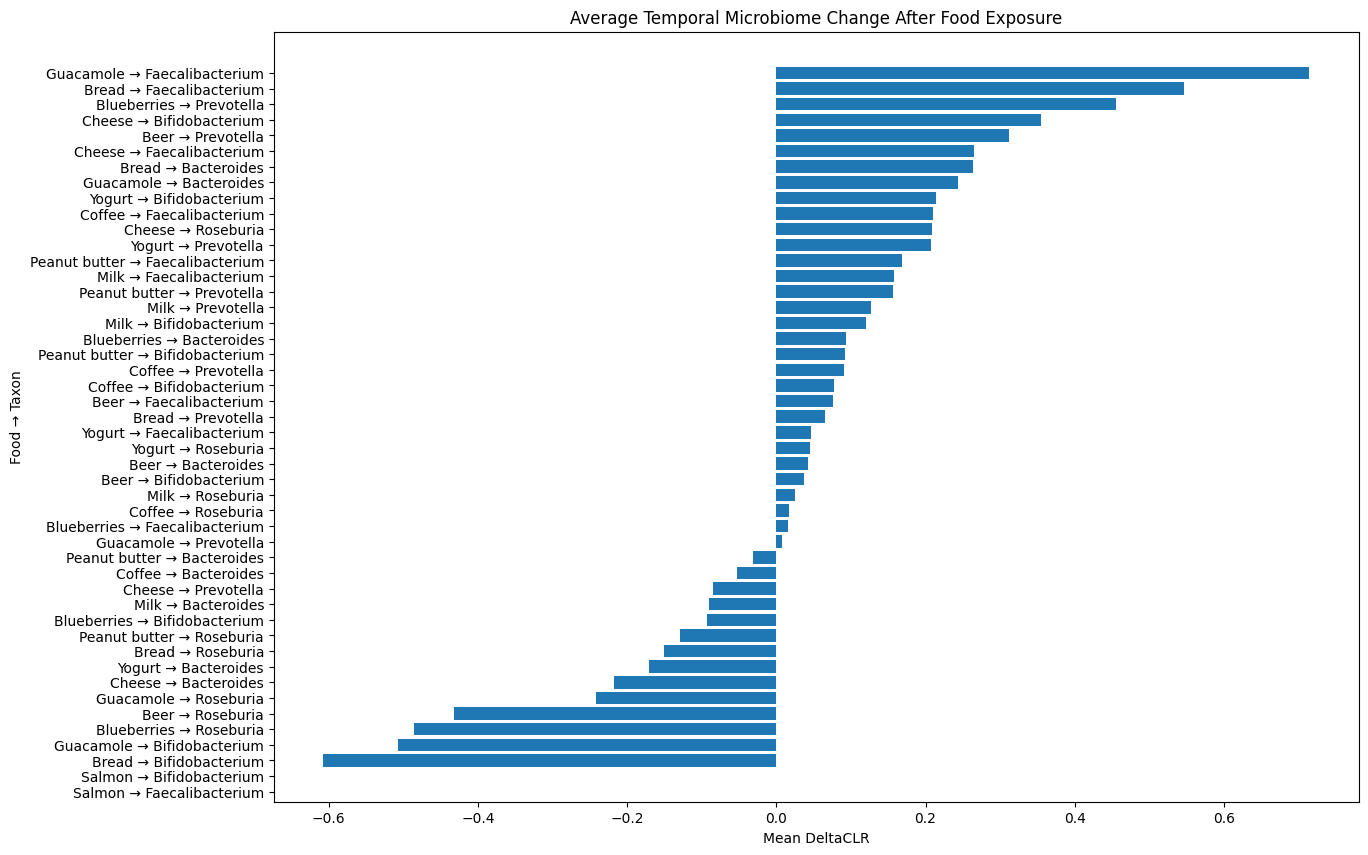


MICROBIOME DIVERSITY ANALYSIS


Goal:
-----
Estimate how microbiome diversity changes over time.


Computing Shannon diversity...

    #SampleID  ShannonDiversity
0  MCT.f.0002          2.862657
1  MCT.f.0003          3.522780
2  MCT.f.0004          3.031031
3  MCT.f.0005          2.974028
4  MCT.f.0006          3.081194

Diversity dataframe preview:
    #SampleID UserName  StudyDayNo  DietDayNo Timing Supplement  oilGrams.assigned PrevSampleID  PrevStudyDay  ShannonDiversity
0  MCT.f.0001   MCTs01           1          0    Pre       EVOO                  0          NaN           NaN               NaN
1  MCT.f.0002   MCTs01           2          1    Pre       EVOO                  0   MCT.f.0001           1.0          2.862657
2  MCT.f.0003   MCTs01           3          2    Pre       EVOO                  0   MCT.f.0002           2.0          3.522780
3  MCT.f.0004   MCTs01           4          3    Pre       EVOO                  0   MCT.f.0003           3.0          3.031031
4  MCT

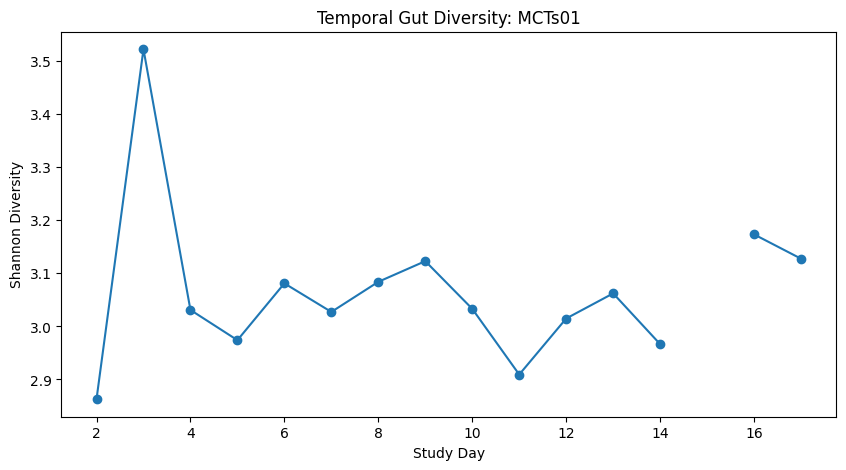


MICROBIOME STABILITY ANALYSIS


Idea:
-----
Stable microbiomes show smaller temporal fluctuations.

We estimate stability using:
    absolute DeltaCLR magnitude

  UserName  MeanAbsoluteChange
0   MCTs01            0.624396
1   MCTs03            0.568274
2   MCTs04            0.626885
3   MCTs05            0.596867
4   MCTs06            1.119990


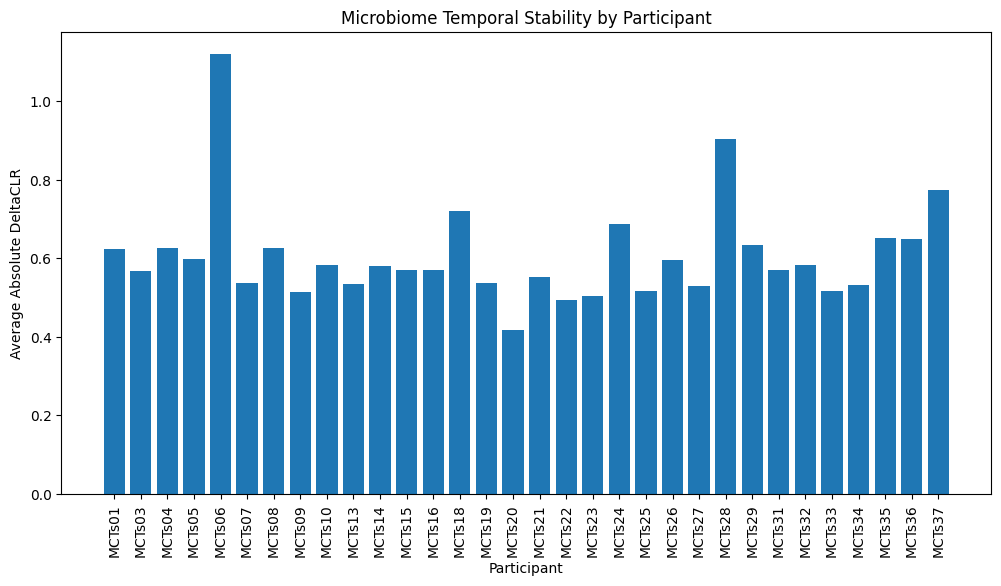


FINAL INTERPRETATION


What this notebook demonstrates:
--------------------------------

1. Longitudinal linking:
   Diet(t-1) → Gut(t)

2. Temporal microbiome change:
   DeltaCLR captures change in bacterial composition.

3. Personalized responses:
   Different people show different microbial responses.

4. Diversity:
   Shannon diversity measures ecological richness/evenness.

5. Stability:
   Smaller temporal fluctuations imply more stable ecosystems.

Important caveats:
------------------
- This is exploratory, not causal.
- CLR values are compositional, not percentages.
- Repeated measures require mixed models for publication-grade inference.
- Food exposure here is observational.
- Multiple-testing correction is not yet applied.



In [40]:
# ============================================================
# LONGITUDINAL FOOD → GUT MICROBIOME EXPLORATORY ANALYSIS
# ============================================================
#
# Goal:
# -----
# Explore how consumption of different foods at time (t-1)
# relates to changes in gut microbiome composition at time (t).
#
# This notebook builds small temporal "experiments":
#
#     Food Exposure(t-1) → Gut Change(t)
#
# using:
# - longitudinal stool microbiome samples
# - daily food intake
# - CLR-transformed species abundances
#
# The analysis is exploratory and NOT causal.
#
# ============================================================



# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from scipy.stats import entropy



# ============================================================
# DISPLAY SETTINGS
# ============================================================

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", 120)



# ============================================================
# PATHS
# ============================================================

BASE = Path("dietstudy_analyses-master")

MAPS = BASE / "data" / "maps"

MICRO = BASE / "data" / "microbiome"

PROC = MICRO / "processed_sample"

PROCRUSTES = BASE / "data" / "procrustes"



# ============================================================
# LOAD MASTER METADATA
# ============================================================

print("\n===================================================")
print("LOADING LONGITUDINAL SAMPLE METADATA")
print("===================================================\n")

food_map = pd.read_csv(
    MAPS / "food_map_no_soy.txt",
    sep="\t"
)

print("Metadata shape:")
print(food_map.shape)

print("\nMetadata preview:")
print(food_map.head())



# ============================================================
# SELECT IMPORTANT COLUMNS
# ============================================================

print("\n===================================================")
print("BUILDING SAMPLE-LEVEL TEMPORAL BACKBONE")
print("===================================================\n")

sample_df = food_map[
    [
        "#SampleID",
        "UserName",
        "StudyDayNo",
        "DietDayNo",
        "Timing",
        "Supplement",
        "oilGrams.assigned"
    ]
].copy()

sample_df = sample_df.sort_values(
    ["UserName", "StudyDayNo"]
)

print("Sample backbone shape:")
print(sample_df.shape)

print("\nSample backbone preview:")
print(sample_df.head(20))



# ============================================================
# CREATE PREVIOUS SAMPLE LINK
# ============================================================

print("\n===================================================")
print("LINKING EACH STOOL SAMPLE TO THE PREVIOUS DAY")
print("===================================================\n")

print("""
Biological meaning:
-------------------
For each participant:
- CurrentSampleID represents gut microbiome at time t
- PrevSampleID represents gut microbiome at time t-1

This allows us to measure microbiome change over time.
""")

sample_df["PrevSampleID"] = (
    sample_df
    .groupby("UserName")["#SampleID"]
    .shift(1)
)

sample_df["PrevStudyDay"] = (
    sample_df
    .groupby("UserName")["StudyDayNo"]
    .shift(1)
)

print(sample_df.head(20))



# ============================================================
# LOAD GUT MICROBIOME DATA
# ============================================================

print("\n===================================================")
print("LOADING CLR-TRANSFORMED GUT MICROBIOME")
print("===================================================\n")

gut_clr = pd.read_csv(
    PROC / "taxonomy_clr_s.txt",
    sep="\t"
)

print("Gut CLR matrix shape:")
print(gut_clr.shape)

print("\nGut CLR preview:")
print(gut_clr.head())



# ============================================================
# CONVERT MICROBIOME MATRIX FROM WIDE TO LONG
# ============================================================

print("\n===================================================")
print("TRANSFORMING GUT MATRIX TO LONG FORMAT")
print("===================================================\n")

print("""
Before:
--------
Rows = bacterial taxa
Columns = stool samples

After:
-------
Each row = one bacterial taxon inside one stool sample
""")

gut_long = gut_clr.melt(
    id_vars="#taxonomy",
    var_name="#SampleID",
    value_name="CLR_abundance"
)

print("Long gut table shape:")
print(gut_long.shape)

print("\nLong gut preview:")
print(gut_long.head())



# ============================================================
# CREATE BEFORE / AFTER GUT STATES
# ============================================================

print("\n===================================================")
print("CREATING GUT BEFORE / AFTER STATES")
print("===================================================\n")

gut_after = gut_long.rename(
    columns={
        "#SampleID": "CurrentSampleID",
        "CLR_abundance": "GutAfterCLR"
    }
)

gut_before = gut_long.rename(
    columns={
        "#SampleID": "PrevSampleID",
        "CLR_abundance": "GutBeforeCLR"
    }
)

temporal_df = sample_df.rename(
    columns={
        "#SampleID": "CurrentSampleID"
    }
)

print("Merging current gut state...")

temporal_df = temporal_df.merge(
    gut_after,
    on="CurrentSampleID",
    how="left"
)

print("Shape after current gut merge:")
print(temporal_df.shape)

print("\nMerging previous gut state...")

temporal_df = temporal_df.merge(
    gut_before,
    on=[
        "PrevSampleID",
        "#taxonomy"
    ],
    how="left"
)

print("Shape after previous gut merge:")
print(temporal_df.shape)



# ============================================================
# COMPUTE MICROBIOME CHANGE
# ============================================================

print("\n===================================================")
print("COMPUTING TEMPORAL MICROBIOME CHANGE")
print("===================================================\n")

print("""
DeltaCLR interpretation:
------------------------
DeltaCLR = GutAfterCLR - GutBeforeCLR

Positive:
----------
Taxon increased relative to the community.

Negative:
----------
Taxon decreased relative to the community.
""")

temporal_df["DeltaCLR"] = (
    temporal_df["GutAfterCLR"]
    - temporal_df["GutBeforeCLR"]
)

print(temporal_df.head())



# ============================================================
# LOAD FOOD DATA
# ============================================================

print("\n===================================================")
print("LOADING FOOD EXPOSURE DATA")
print("===================================================\n")

food_file = (
    PROCRUSTES
    / "data_username_1day"
    / "MCTs01_food.txt"
)

food_1 = pd.read_csv(
    food_file,
    sep="\t"
)

print("Food matrix shape:")
print(food_1.shape)

print("\nFood matrix preview:")
print(food_1.head())



# ============================================================
# CONVERT FOOD MATRIX TO LONG FORMAT
# ============================================================

print("\n===================================================")
print("TRANSFORMING FOOD MATRIX TO LONG FORMAT")
print("===================================================\n")

food_long = food_1.melt(
    id_vars=["#FoodID", "taxonomy"],
    var_name="#SampleID",
    value_name="food_grams"
)

food_long = food_long[
    food_long["food_grams"] > 0
]

print("Food long table shape:")
print(food_long.shape)

print("\nFood long preview:")
print(food_long.head())



# ============================================================
# MERGE FOOD WITH METADATA
# ============================================================

print("\n===================================================")
print("MERGING FOOD EXPOSURE WITH SAMPLE METADATA")
print("===================================================\n")

food_meta = food_long.merge(
    food_map,
    on="#SampleID",
    how="inner"
)

print("Merged food metadata shape:")
print(food_meta.shape)

print("\nFood metadata preview:")
print(food_meta.head())



# ============================================================
# DEFINE TARGET FOODS
# ============================================================

print("\n===================================================")
print("DEFINING TARGET FOODS")
print("===================================================\n")

target_foods = [
    "Yogurt",
    "Cheese",
    "Coffee",
    "Beer",
    "Milk",
    "Peanut butter",
    "Salmon",
    "Bread",
    "Blueberries",
    "Guacamole"
]

print(target_foods)



# ============================================================
# DEFINE TARGET TAXA
# ============================================================

print("\n===================================================")
print("DEFINING TARGET MICROBIAL TAXA")
print("===================================================\n")

target_taxa = [
    "Bifidobacterium",
    "Faecalibacterium",
    "Roseburia",
    "Bacteroides",
    "Prevotella"
]

print(target_taxa)



# ============================================================
# RUN FOOD → MICROBIOME EXPERIMENTS
# ============================================================

all_results = []

print("\n===================================================")
print("RUNNING TEMPORAL FOOD → GUT EXPERIMENTS")
print("===================================================\n")

for food_name in target_foods:

    print("\n---------------------------------------------------")
    print(f"ANALYZING FOOD: {food_name}")
    print("---------------------------------------------------")

    food_subset = food_meta[
        food_meta["#FoodID"]
        .str.contains(food_name, case=False, na=False)
    ].copy()

    print(f"\nRows containing '{food_name}':")
    print(food_subset.shape[0])

    if len(food_subset) == 0:
        print("No matching food found.")
        continue

    for taxon in target_taxa:

        tax_subset = temporal_df[
            temporal_df["#taxonomy"]
            .str.contains(taxon, case=False, na=False)
        ].copy()

        experiment_df = food_subset.merge(
            tax_subset,
            left_on="#SampleID",
            right_on="CurrentSampleID",
            how="inner"
        )

        if len(experiment_df) == 0:
            continue

        mean_delta = experiment_df["DeltaCLR"].mean()

        median_delta = experiment_df["DeltaCLR"].median()

        std_delta = experiment_df["DeltaCLR"].std()

        n_obs = len(experiment_df)

        all_results.append({
            "Food": food_name,
            "Taxon": taxon,
            "N": n_obs,
            "MeanDeltaCLR": mean_delta,
            "MedianDeltaCLR": median_delta,
            "StdDeltaCLR": std_delta
        })

        print(f"\nFood: {food_name}")
        print(f"Taxon: {taxon}")

        print(f"""
Interpretation:
---------------
This tests whether eating:
    {food_name}

is associated with temporal change in:
    {taxon}

between consecutive stool samples.
""")

        print(f"Number of observations: {n_obs}")

        print(f"Mean DeltaCLR: {mean_delta:.3f}")

        print(f"Median DeltaCLR: {median_delta:.3f}")

        print(f"Standard deviation: {std_delta:.3f}")



# ============================================================
# BUILD RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(all_results)

print("\n===================================================")
print("FINAL RESULTS TABLE")
print("===================================================\n")

print(results_df.head(20))



# ============================================================
# TOP POSITIVE ASSOCIATIONS
# ============================================================

print("\n===================================================")
print("TOP POSITIVE FOOD → TAXON ASSOCIATIONS")
print("===================================================\n")

top_positive = results_df.sort_values(
    "MeanDeltaCLR",
    ascending=False
).head(15)

print(top_positive)



# ============================================================
# TOP NEGATIVE ASSOCIATIONS
# ============================================================

print("\n===================================================")
print("TOP NEGATIVE FOOD → TAXON ASSOCIATIONS")
print("===================================================\n")

top_negative = results_df.sort_values(
    "MeanDeltaCLR",
    ascending=True
).head(15)

print(top_negative)



# ============================================================
# VISUALIZATION: FOOD → TAXON EFFECTS
# ============================================================

print("\n===================================================")
print("VISUALIZING FOOD → TAXON EFFECTS")
print("===================================================\n")

plot_df = results_df.sort_values(
    "MeanDeltaCLR",
    ascending=False
)

labels = (
    plot_df["Food"]
    + " → "
    + plot_df["Taxon"]
)

plt.figure(figsize=(14, 10))

plt.barh(
    labels,
    plot_df["MeanDeltaCLR"]
)

plt.xlabel("Mean DeltaCLR")

plt.ylabel("Food → Taxon")

plt.title("Average Temporal Microbiome Change After Food Exposure")

plt.gca().invert_yaxis()

plt.show()



# ============================================================
# MICROBIOME DIVERSITY ANALYSIS
# ============================================================

print("\n===================================================")
print("MICROBIOME DIVERSITY ANALYSIS")
print("===================================================\n")

print("""
Goal:
-----
Estimate how microbiome diversity changes over time.
""")



# ============================================================
# COMPUTE SHANNON DIVERSITY
# ============================================================

print("\nComputing Shannon diversity...\n")

gut_norm = pd.read_csv(
    PROC / "taxonomy_norm_s.txt",
    sep="\t"
)

gut_norm_long = gut_norm.melt(
    id_vars="#taxonomy",
    var_name="#SampleID",
    value_name="abundance"
)

shannon_results = []

for sample_id, group in gut_norm_long.groupby("#SampleID"):

    abundances = group["abundance"].values

    abundances = abundances[abundances > 0]

    if len(abundances) == 0:
        continue

    shannon = entropy(abundances)

    shannon_results.append({
        "#SampleID": sample_id,
        "ShannonDiversity": shannon
    })

shannon_df = pd.DataFrame(shannon_results)

print(shannon_df.head())



# ============================================================
# MERGE DIVERSITY INTO SAMPLE METADATA
# ============================================================

diversity_df = sample_df.merge(
    shannon_df,
    left_on="#SampleID",
    right_on="#SampleID",
    how="left"
)

print("\nDiversity dataframe preview:")
print(diversity_df.head())



# ============================================================
# VISUALIZE DIVERSITY OVER TIME
# ============================================================

print("\n===================================================")
print("VISUALIZING MICROBIOME DIVERSITY OVER TIME")
print("===================================================\n")

example_user = diversity_df["UserName"].iloc[0]

user_div = diversity_df[
    diversity_df["UserName"] == example_user
]

plt.figure(figsize=(10, 5))

plt.plot(
    user_div["StudyDayNo"],
    user_div["ShannonDiversity"],
    marker="o"
)

plt.xlabel("Study Day")

plt.ylabel("Shannon Diversity")

plt.title(f"Temporal Gut Diversity: {example_user}")

plt.show()



# ============================================================
# MICROBIOME STABILITY ANALYSIS
# ============================================================

print("\n===================================================")
print("MICROBIOME STABILITY ANALYSIS")
print("===================================================\n")

print("""
Idea:
-----
Stable microbiomes show smaller temporal fluctuations.

We estimate stability using:
    absolute DeltaCLR magnitude
""")

stability_df = temporal_df.copy()

stability_df["AbsDelta"] = (
    stability_df["DeltaCLR"]
    .abs()
)

stability_summary = (
    stability_df
    .groupby("UserName")["AbsDelta"]
    .mean()
    .reset_index()
)

stability_summary.columns = [
    "UserName",
    "MeanAbsoluteChange"
]

print(stability_summary.head())



# ============================================================
# VISUALIZE STABILITY
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    stability_summary["UserName"],
    stability_summary["MeanAbsoluteChange"]
)

plt.xticks(rotation=90)

plt.ylabel("Average Absolute DeltaCLR")

plt.xlabel("Participant")

plt.title("Microbiome Temporal Stability by Participant")

plt.show()



# ============================================================
# FINAL INTERPRETATION
# ============================================================

print("\n===================================================")
print("FINAL INTERPRETATION")
print("===================================================\n")

print("""
What this notebook demonstrates:
--------------------------------

1. Longitudinal linking:
   Diet(t-1) → Gut(t)

2. Temporal microbiome change:
   DeltaCLR captures change in bacterial composition.

3. Personalized responses:
   Different people show different microbial responses.

4. Diversity:
   Shannon diversity measures ecological richness/evenness.

5. Stability:
   Smaller temporal fluctuations imply more stable ecosystems.

Important caveats:
------------------
- This is exploratory, not causal.
- CLR values are compositional, not percentages.
- Repeated measures require mixed models for publication-grade inference.
- Food exposure here is observational.
- Multiple-testing correction is not yet applied.
""")


1. LOADING METADATA & MICROBIOME DATA

Loaded Metadata: (532, 29)
Loaded Gut CLR: (223, 484)
Loaded Gut NORM: (223, 484)

2. PARSING TAXONOMY STRINGS

Parsing taxonomy hierarchy for all microorganisms...
Taxonomy parsing complete. Preview:
                                                                                                                 #taxonomy          Phylum              Family            Genus
0                                                                                            k__Bacteria;NA;NA;NA;NA;NA;NA         Unknown             Unknown          Unknown
1         k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA  Actinobacteria  Bifidobacteriaceae  Bifidobacterium
2  k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bif...  Actinobacteria  Bifidobacteriaceae  Bifidobacterium
3  k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__B

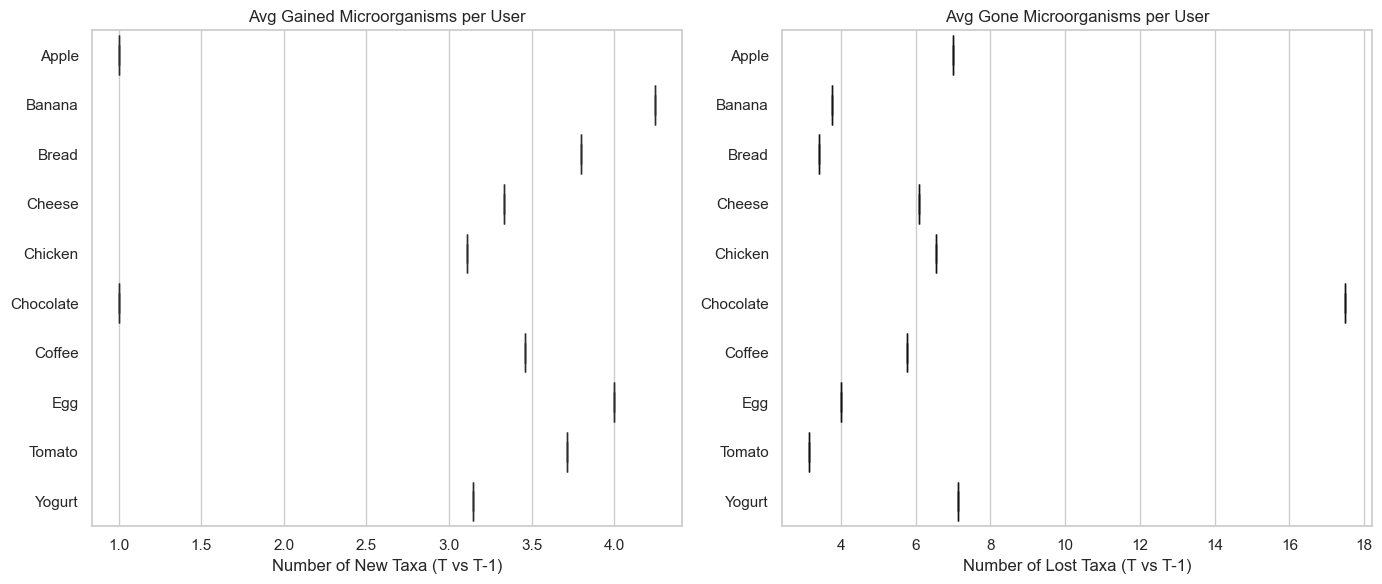

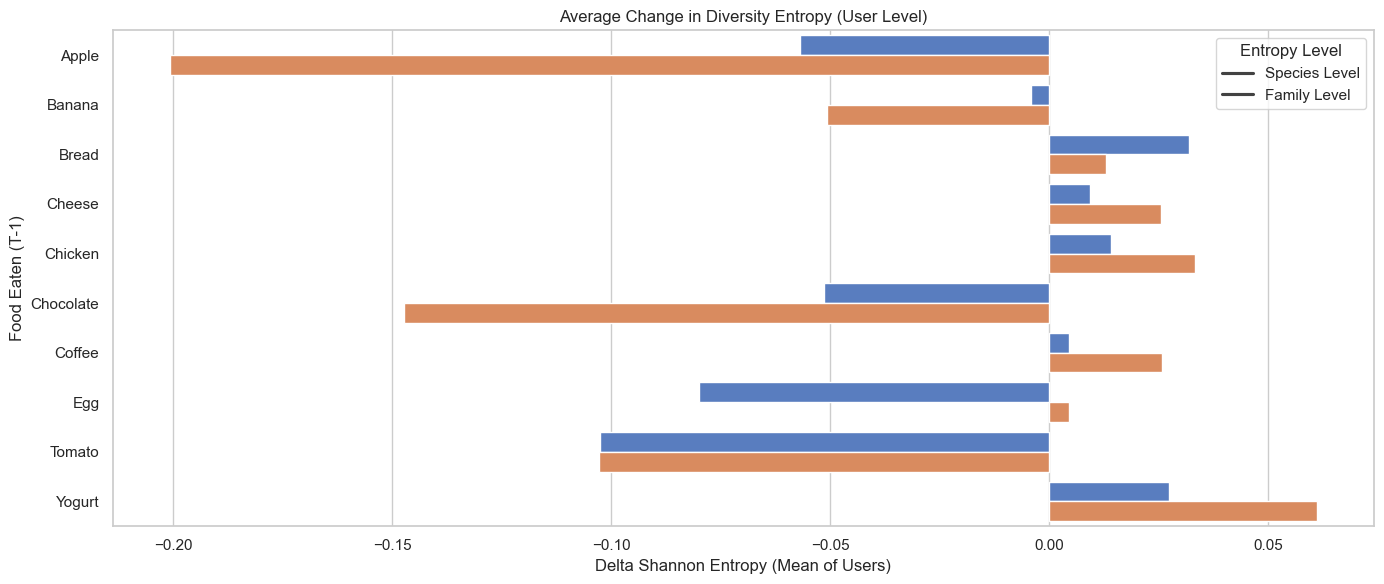

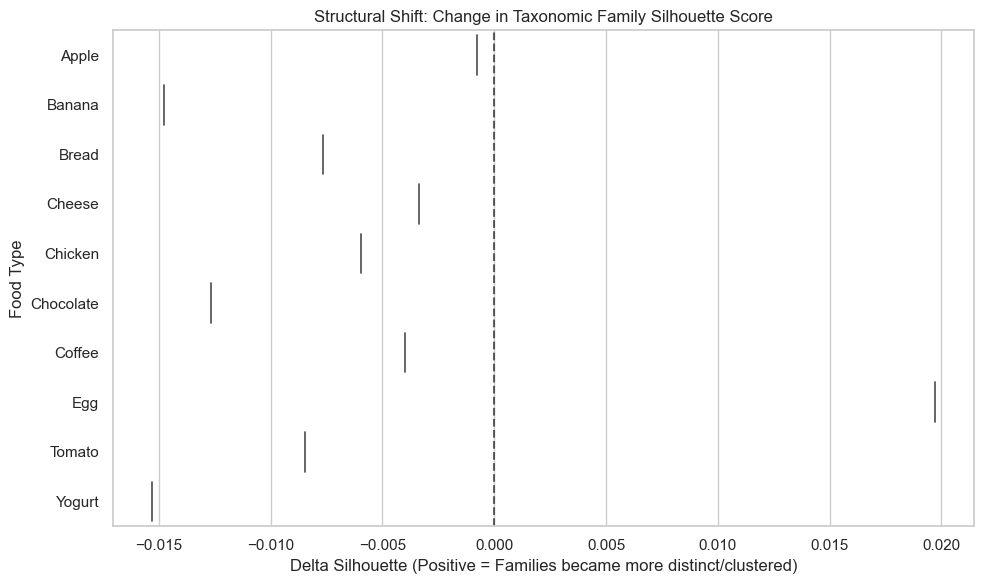

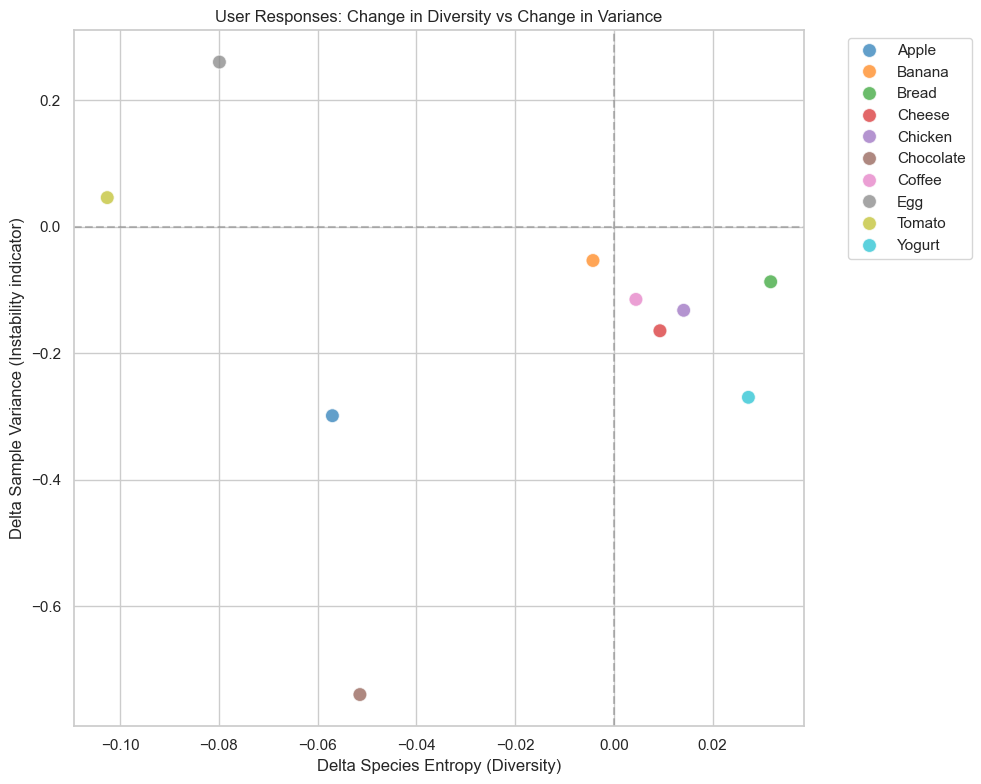


ANALYSIS COMPLETE.



In [41]:
# ============================================================
# ADVANCED LONGITUDINAL FOOD → MICROBIOME ANALYSIS
# Stability, Diversity, and Structure Impact
# ============================================================
#
# Goal:
# -----
# Evaluate the impact of 10 different foods on the gut microbiome
# by calculating the average effect per individual user across 
# three main pillars:
# 1. Stability (Gained/Lost taxa, variance change)
# 2. Diversity (Richness, Entropy at Species/Family levels)
# 3. Structure (Silhouette scores between families, Family Entropy)
#
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import entropy
from sklearn.metrics import silhouette_score
import sys
import warnings

# Suppress warnings for cleaner output during calculations
warnings.filterwarnings('ignore')

# ============================================================
# DISPLAY & PLOT SETTINGS
# ============================================================
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 250)
sns.set_theme(style="whitegrid")

# ============================================================
# PATHS
# ============================================================
BASE = Path("dietstudy_analyses-master")
MAPS = BASE / "data" / "maps"
MICRO = BASE / "data" / "microbiome"
PROC = MICRO / "processed_sample"
PROCRUSTES = BASE / "data" / "procrustes"

print("\n===================================================")
print("1. LOADING METADATA & MICROBIOME DATA")
print("===================================================\n")

# Load Metadata
map_file = MAPS / "food_map_no_soy.txt"
if not map_file.exists():
    sys.exit(f"ERROR: Missing map file at {map_file.resolve()}")
food_map = pd.read_csv(map_file, sep="\t")

# Load CLR and Normalized Microbiome Data
clr_file = PROC / "taxonomy_clr_s.txt"
norm_file = PROC / "taxonomy_norm_s.txt"

if not clr_file.exists() or not norm_file.exists():
    sys.exit("ERROR: Missing microbiome files (CLR or NORM).")

gut_clr = pd.read_csv(clr_file, sep="\t")
gut_norm = pd.read_csv(norm_file, sep="\t")

print(f"Loaded Metadata: {food_map.shape}")
print(f"Loaded Gut CLR: {gut_clr.shape}")
print(f"Loaded Gut NORM: {gut_norm.shape}")

# ============================================================
# TAXONOMY PARSER FUNCTION
# ============================================================
print("\n===================================================")
print("2. PARSING TAXONOMY STRINGS")
print("===================================================\n")

def parse_taxonomy(tax_str):
    """
    Splits taxonomy string into structural dictionary.
    Example: k__Bacteria;p__Actinobacteria;...;f__Bifidobacteriaceae;...
    """
    ranks = {'k': 'Kingdom', 'p': 'Phylum', 'c': 'Class', 
             'o': 'Order', 'f': 'Family', 'g': 'Genus', 's': 'Species'}
    parsed = {val: "Unknown" for val in ranks.values()}
    
    parts = str(tax_str).split(';')
    for part in parts:
        if '__' in part:
            lvl, name = part.split('__', 1)
            lvl = lvl.strip()
            name = name.strip()
            if lvl in ranks and name:
                parsed[ranks[lvl]] = name
    return pd.Series(parsed)

print("Parsing taxonomy hierarchy for all microorganisms...")
taxa_info = gut_clr[['#taxonomy']].copy()
taxa_parsed = taxa_info['#taxonomy'].apply(parse_taxonomy)
taxa_df = pd.concat([taxa_info, taxa_parsed], axis=1)

print("Taxonomy parsing complete. Preview:")
print(taxa_df[['#taxonomy', 'Phylum', 'Family', 'Genus']].head())

# ============================================================
# COMPUTE SAMPLE-LEVEL INDEXES (CROSS-SECTIONAL)
# ============================================================
print("\n===================================================")
print("3. COMPUTING DIVERSITY & STRUCTURE INDEXES PER SAMPLE")
print("===================================================\n")

# Melt matrices to long format
clr_long = gut_clr.melt(id_vars="#taxonomy", var_name="#SampleID", value_name="CLR")
norm_long = gut_norm.melt(id_vars="#taxonomy", var_name="#SampleID", value_name="NORM")

# Merge CLR, NORM and Taxonomy info
sample_micro = clr_long.merge(norm_long, on=["#taxonomy", "#SampleID"])
sample_micro = sample_micro.merge(taxa_df, on="#taxonomy")

sample_indexes = []

print("Calculating structural and diversity indexes for each sample...")
# Group by sample to calculate metrics
for sample_id, group in sample_micro.groupby("#SampleID"):
    
    # Filter only present taxa for diversity/structure metrics
    present = group[group["NORM"] > 0]
    
    if len(present) == 0:
        continue
        
    # --- Diversity Indexes ---
    num_micro = len(present)
    num_families = present['Family'].nunique()
    
    entropy_micro = entropy(present["NORM"].values)
    
    # Family level entropy
    family_abundances = present.groupby('Family')["NORM"].sum().values
    entropy_family = entropy(family_abundances)
    
    # --- Structure Indexes ---
    # Silhouette Score: How well defined are the family clusters based on CLR abundance?
    # Requires at least 2 families and >2 samples. We use CLR as the 1D feature.
    sil_score = np.nan
    if num_families > 1 and num_micro > 2:
        try:
            features = present["CLR"].values.reshape(-1, 1)
            labels = present["Family"].values
            sil_score = silhouette_score(features, labels)
        except:
            pass # Fails if a family has only 1 sample or other edge cases
            
    # Variance of the sample (Stability baseline)
    sample_variance = present["CLR"].var()
    
    sample_indexes.append({
        "#SampleID": sample_id,
        "NumMicroorganisms": num_micro,
        "NumFamilies": num_families,
        "EntropyMicro": entropy_micro,
        "EntropyFamily": entropy_family,
        "StructureSilhouette": sil_score,
        "SampleVariance": sample_variance
    })

indexes_df = pd.DataFrame(sample_indexes)
print(f"Computed metrics for {len(indexes_df)} samples.")
print(indexes_df.head())

# ============================================================
# BUILD TEMPORAL BACKBONE (T-1 -> T)
# ============================================================
print("\n===================================================")
print("4. BUILDING TEMPORAL BACKBONE & CALCULATING DELTAS")
print("===================================================\n")

sample_df = food_map[["#SampleID", "UserName", "StudyDayNo"]].copy()
sample_df = sample_df.sort_values(["UserName", "StudyDayNo"])
sample_df["PrevSampleID"] = sample_df.groupby("UserName")["#SampleID"].shift(1)

# Drop first days (no previous day to compare to)
temporal_df = sample_df.dropna(subset=["PrevSampleID"]).copy()

# Merge metrics for Time T (Current)
temporal_df = temporal_df.merge(
    indexes_df.add_suffix("_T"), 
    left_on="#SampleID", right_on="#SampleID_T", how="left"
)

# Merge metrics for Time T-1 (Previous)
temporal_df = temporal_df.merge(
    indexes_df.add_suffix("_T_minus_1"), 
    left_on="PrevSampleID", right_on="#SampleID_T_minus_1", how="left"
)

# --- Calculate Delta Indexes (Change over time) ---
temporal_df["Delta_EntropyMicro"] = temporal_df["EntropyMicro_T"] - temporal_df["EntropyMicro_T_minus_1"]
temporal_df["Delta_EntropyFamily"] = temporal_df["EntropyFamily_T"] - temporal_df["EntropyFamily_T_minus_1"]
temporal_df["Delta_NumFamilies"] = temporal_df["NumFamilies_T"] - temporal_df["NumFamilies_T_minus_1"]
temporal_df["Delta_Silhouette"] = temporal_df["StructureSilhouette_T"] - temporal_df["StructureSilhouette_T_minus_1"]
temporal_df["Delta_Variance"] = temporal_df["SampleVariance_T"] - temporal_df["SampleVariance_T_minus_1"]

# --- Calculate Gained/Lost Microorganisms ---
print("Calculating stability indexes: Gained and Gone microorganisms per temporal jump...")

# Pivot NORM data to wide format for easy T vs T-1 comparison
norm_wide = gut_norm.set_index("#taxonomy")
gained_lost_data = []

for idx, row in temporal_df.iterrows():
    curr_id = row["#SampleID"]
    prev_id = row["PrevSampleID"]
    
    if curr_id in norm_wide.columns and prev_id in norm_wide.columns:
        prev_abun = norm_wide[prev_id]
        curr_abun = norm_wide[curr_id]
        
        gained = ((prev_abun == 0) & (curr_abun > 0)).sum()
        gone = ((prev_abun > 0) & (curr_abun == 0)).sum()
        
        # Avg absolute change in CLR (Volatility) - Proxy for avg % change
        # using CLR_wide (re-pivot clr for this)
    else:
        gained = np.nan
        gone = np.nan
        
    gained_lost_data.append({
        "#SampleID": curr_id,
        "NumGainedMicro": gained,
        "NumGoneMicro": gone
    })

temporal_df = temporal_df.merge(pd.DataFrame(gained_lost_data), on="#SampleID")
print("Temporal deltas calculated successfully.")

# ============================================================
# LOAD FOOD DATA & SELECT 10 TARGET FOODS
# ============================================================
print("\n===================================================")
print("5. LOADING FOOD EXPOSURE (T-1)")
print("===================================================\n")

food_file = PROCRUSTES / "data_username_1day" / "MCTs01_food.txt"
if not food_file.exists():
    sys.exit(f"ERROR: Missing food file at {food_file.resolve()}")

food_df = pd.read_csv(food_file, sep="\t")
food_long = food_df.melt(id_vars=["#FoodID", "taxonomy"], var_name="PrevSampleID", value_name="food_grams")
food_long = food_long[food_long["food_grams"] > 0] # Only keep foods eaten

# Target 10 diverse foods
target_foods = [
    "Yogurt", "Cheese", "Coffee", "Egg", "Banana",
    "Tomato", "Bread", "Apple", "Chicken", "Chocolate"
]

print(f"Target Foods for Analysis: {target_foods}")

# Create an empty dataframe to hold combined experimental data
experiments = pd.DataFrame()

for food_name in target_foods:
    food_subset = food_long[food_long["#FoodID"].str.contains(food_name, case=False, na=False)]
    
    if len(food_subset) == 0:
        continue
        
    # We group by PrevSampleID just in case a food appears twice in one day
    food_eaten = food_subset.groupby("PrevSampleID", as_index=False)["food_grams"].sum()
    food_eaten["FoodType"] = food_name
    
    # Merge with temporal backbone (Linking Food eaten at T-1 to Delta T)
    merged = temporal_df.merge(food_eaten, on="PrevSampleID", how="inner")
    experiments = pd.concat([experiments, merged], ignore_index=True)

# ============================================================
# USER-LEVEL AGGREGATION
# ============================================================
print("\n===================================================")
print("6. AGGREGATING AVERAGE EFFECT PER USER")
print("===================================================\n")

print("Averaging the impact of each food per individual person (UserName)...")

# Define columns we want to analyze
metrics_to_analyze = [
    "NumGainedMicro", "NumGoneMicro", "Delta_Variance", # Stability
    "Delta_EntropyMicro", "Delta_EntropyFamily", "Delta_NumFamilies", # Diversity
    "Delta_Silhouette" # Structure
]

# Group by User and Food, then take the mean
user_food_avg = experiments.groupby(["UserName", "FoodType"])[metrics_to_analyze].mean().reset_index()

# Now group by Food to see the overall "Average of User Averages"
food_global_avg = user_food_avg.groupby("FoodType")[metrics_to_analyze].mean().reset_index()

print("Global Average Impact (Mean of Users) per Food:")
print(food_global_avg)

# ============================================================
# VISUALIZATIONS
# ============================================================
print("\n===================================================")
print("7. GENERATING VISUALIZATIONS")
print("===================================================\n")

# Setup 1: Stability - Gained vs Gone Microorganisms
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=user_food_avg, x="NumGainedMicro", y="FoodType", palette="viridis")
plt.title("Avg Gained Microorganisms per User")
plt.xlabel("Number of New Taxa (T vs T-1)")
plt.ylabel("")

plt.subplot(1, 2, 2)
sns.boxplot(data=user_food_avg, x="NumGoneMicro", y="FoodType", palette="magma")
plt.title("Avg Gone Microorganisms per User")
plt.xlabel("Number of Lost Taxa (T vs T-1)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Setup 2: Diversity - Species vs Family Entropy Shifts
plt.figure(figsize=(14, 6))
melted_div = user_food_avg.melt(id_vars=["UserName", "FoodType"], 
                                value_vars=["Delta_EntropyMicro", "Delta_EntropyFamily"],
                                var_name="Metric", value_name="Change")

sns.barplot(data=melted_div, x="Change", y="FoodType", hue="Metric", errorbar='ci', palette="muted")
plt.title("Average Change in Diversity Entropy (User Level)")
plt.xlabel("Delta Shannon Entropy (Mean of Users)")
plt.ylabel("Food Eaten (T-1)")
plt.legend(title="Entropy Level", labels=["Species Level", "Family Level"])
plt.tight_layout()
plt.show()

# Setup 3: Structure - Silhouette Score shifts (Clustering quality of families)
plt.figure(figsize=(10, 6))
sns.violinplot(data=user_food_avg, x="Delta_Silhouette", y="FoodType", palette="coolwarm", inner="quartile")
plt.axvline(0, color='black', linestyle='--', alpha=0.6)
plt.title("Structural Shift: Change in Taxonomic Family Silhouette Score")
plt.xlabel("Delta Silhouette (Positive = Families became more distinct/clustered)")
plt.ylabel("Food Type")
plt.tight_layout()
plt.show()

# Setup 4: Multi-metric Scatter Plot (Diversity vs Stability)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=user_food_avg, 
    x="Delta_EntropyMicro", 
    y="Delta_Variance", 
    hue="FoodType", 
    palette="tab10",
    s=100, alpha=0.7
)
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.title("User Responses: Change in Diversity vs Change in Variance")
plt.xlabel("Delta Species Entropy (Diversity)")
plt.ylabel("Delta Sample Variance (Instability indicator)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n===================================================")
print("ANALYSIS COMPLETE.")
print("===================================================\n")